# PRAICP-1000-IndiSignLang — EDA & Model Development (Keras)
**DataMites Project PR-0019 — Indian Sign Language Recognition**

**Project Goal (from brief):**
1. Image preprocessing
2. ML model to predict the sign

This notebook covers: Exploratory Data Analysis (EDA) → preprocessing → a simple CNN
built from scratch in Keras → training → evaluation.

Uses the split data created in `ISL_Data_Preparation.ipynb` (`Split_Data/train`, `/val`, `/test`).

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# ---- EDIT THESE to match your folder location ----
DATA_DIR = r"G:\Deep-Learning-Projects\IndiSignLang\Data"
SPLIT_DIR = r"G:\Deep-Learning-Projects\IndiSignLang\Split_Data"


TensorFlow version: 2.21.0
GPU available: []


**Observations:**
1. `DATA_DIR` points to the raw class folders (A, B, C...); `SPLIT_DIR` points to the already-split train/val/test folders from Notebook 1 — both are needed here since EDA looks at raw data first.
2. `GPU available` may print an empty list — that's fine, training will just run on CPU and take longer.
3. If `tensorflow` or `seaborn` aren't installed, run `pip install tensorflow seaborn --break-system-packages` in a terminal first.

## 2. EDA — Class Distribution

C:\Users\91706\AppData\Local\Temp\ipykernel_29684\2139742301.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df, x="Class", y="Count", palette="viridis")


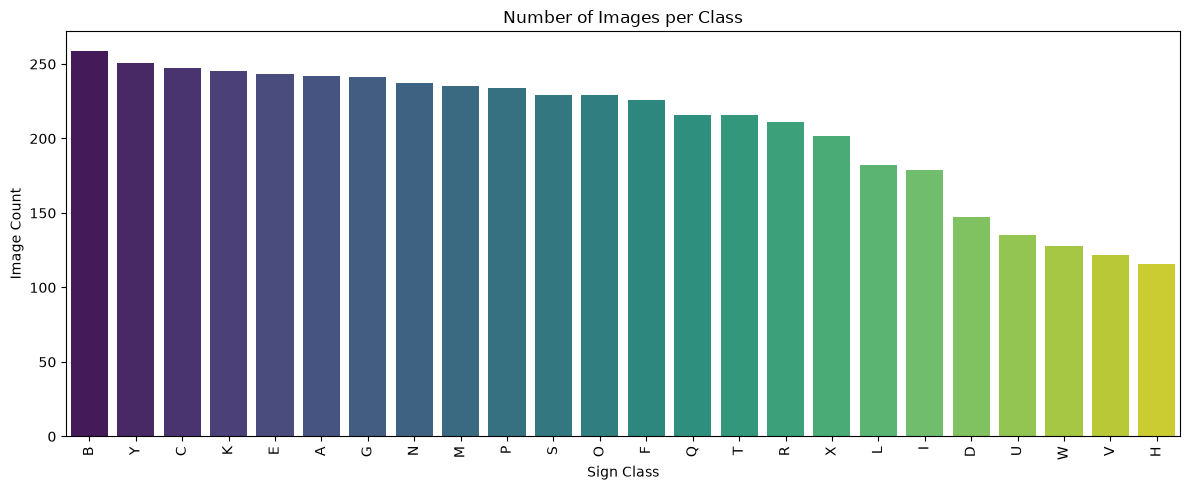

Total classes: 24
Total images: 4972
Min class: H -> 116
Max class: B -> 259


In [2]:
class_counts = {}
for cls in sorted(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[cls] = n

counts_df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"]).sort_values("Count", ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=counts_df, x="Class", y="Count", palette="viridis")
plt.title("Number of Images per Class")
plt.xlabel("Sign Class")
plt.ylabel("Image Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Total classes:", len(class_counts))
print("Total images:", sum(class_counts.values()))
print("Min class:", counts_df.iloc[-1]['Class'], "->", counts_df.iloc[-1]['Count'])
print("Max class:", counts_df.iloc[0]['Class'], "->", counts_df.iloc[0]['Count'])


**Observations:**
1. This shows whether the dataset is balanced across classes — a big gap between the tallest and shortest bar means some signs are under-represented, which can bias the model toward predicting majority classes more often.
2. Note down the min and max class here — you'll refer back to these when checking per-class performance in the evaluation section later (weak classes often overlap with low-count classes).
3. This graph directly satisfies the 'understand your data before modeling' expectation in any data science project write-up.

## 3. EDA — Image Dimensions & File Sizes

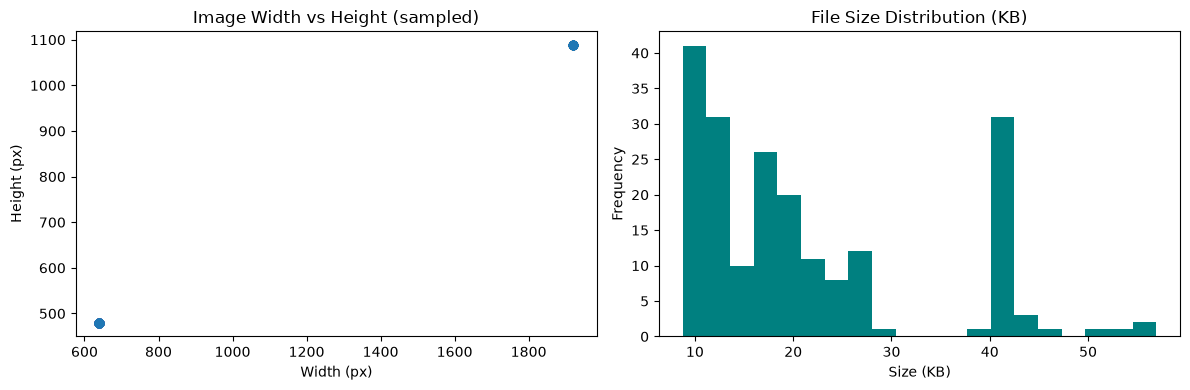

            width      height     size_kb
count   200.00000   200.00000  200.000000
mean    896.00000   601.60000   21.278721
std     513.28482   243.81029   11.866351
min     640.00000   480.00000    8.744141
25%     640.00000   480.00000   11.894043
50%     640.00000   480.00000   17.154297
75%     640.00000   480.00000   25.874756
max    1920.00000  1088.00000   56.944336


In [3]:
dimension_records = []

for cls in sorted(os.listdir(DATA_DIR))[:5]:   # sample first 5 classes to keep this fast
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in files[:40]:   # sample 40 images per class
        fpath = os.path.join(cls_path, f)
        try:
            with Image.open(fpath) as img:
                w, h = img.size
                size_kb = os.path.getsize(fpath) / 1024
                dimension_records.append({"class": cls, "width": w, "height": h, "size_kb": size_kb})
        except Exception:
            pass

dim_df = pd.DataFrame(dimension_records)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(dim_df["width"], dim_df["height"], alpha=0.4)
axes[0].set_title("Image Width vs Height (sampled)")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")

axes[1].hist(dim_df["size_kb"], bins=20, color="teal")
axes[1].set_title("File Size Distribution (KB)")
axes[1].set_xlabel("Size (KB)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(dim_df[["width", "height", "size_kb"]].describe())


**Observations:**
1. If all points cluster tightly in one spot on the width-vs-height scatter, images are already a consistent resolution good, means less risk of distortion when we resize everything to one fixed size later.
2. The file size histogram indicates compression consistency a wide spread could mean some images are much higher/lower quality than others, worth being aware of but not necessarily a problem.
3. This is only sampled (5 classes, 40 images each) to keep the cell fast it's a representative check, not an exhaustive one, and that's a reasonable trade-off to mention in your report.

## 4. EDA — Sample Images Across Multiple Classes

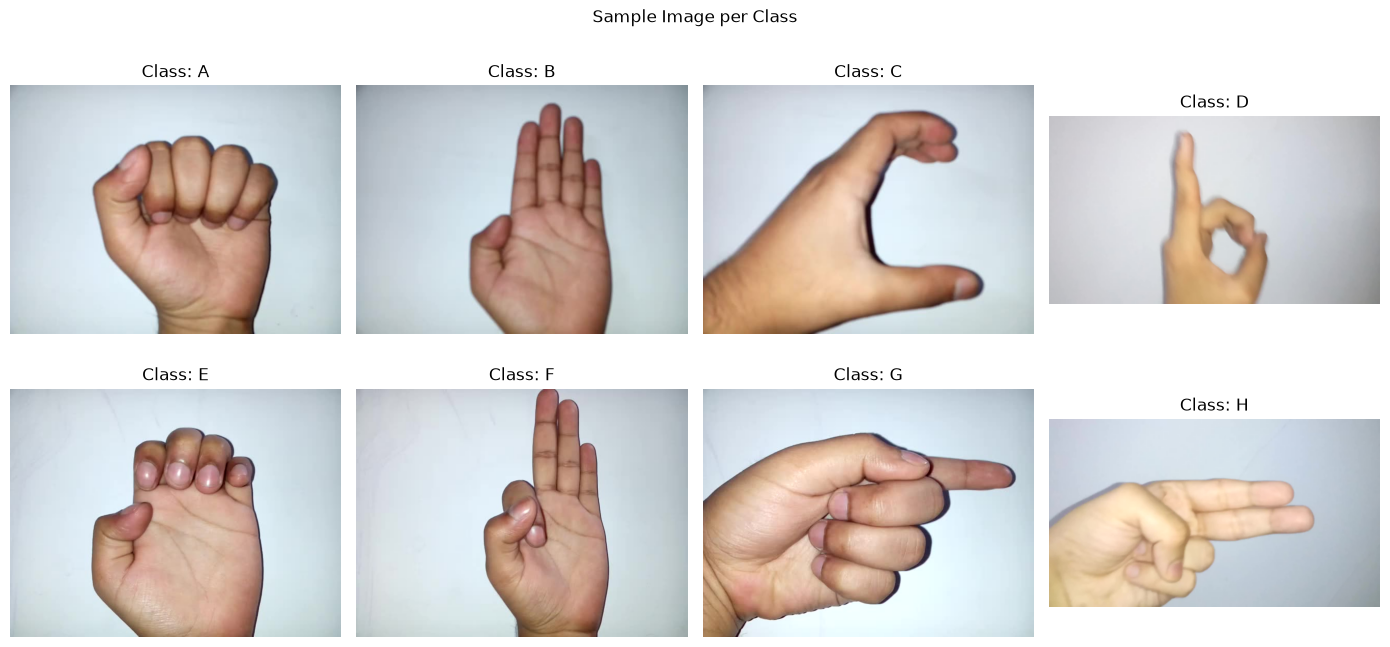

In [4]:
sample_classes = sorted(os.listdir(DATA_DIR))[:8]   # first 8 classes

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, cls in zip(axes, sample_classes):
    cls_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img = Image.open(os.path.join(cls_path, files[0]))
    ax.imshow(img)
    ax.set_title(f"Class: {cls}")
    ax.axis('off')

plt.suptitle("Sample Image per Class")
plt.tight_layout()
plt.show()


**Observations:**
1. Visually confirms each class folder actually contains the correct, distinct hand sign an important manual check before trusting the labels blindly.
2. Look for any two classes that look nearly identical (e.g. similar fist/finger shapes) those are early warning signs of classes the model may confuse later, worth flagging in your report.
3. Since backgrounds and lighting look similar across classes, the model should be learning hand shape rather than background — good, as background shouldn't be a shortcut signal.

## 5. EDA — Pixel Intensity Distribution

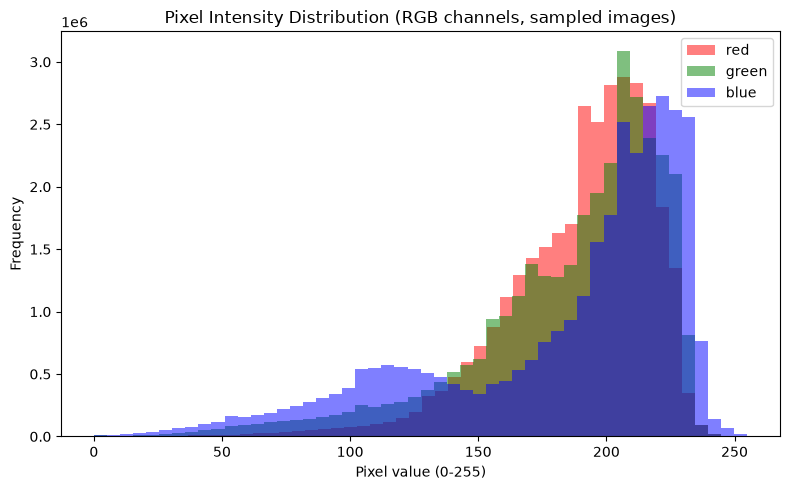

In [5]:
sample_pixels = []

for cls in sorted(os.listdir(DATA_DIR))[:5]:
    cls_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in files[:10]:
        img = Image.open(os.path.join(cls_path, f)).convert("RGB")
        arr = np.array(img).reshape(-1, 3)
        sample_pixels.append(arr)

all_pixels = np.vstack(sample_pixels)

plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    plt.hist(all_pixels[:, i], bins=50, alpha=0.5, label=color, color=color)
plt.title("Pixel Intensity Distribution (RGB channels, sampled images)")
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


**Observations:**
1. This shows the overall brightness/color balance across sampled images — if channels are heavily skewed toward one end (e.g. mostly bright values), it confirms the grey/light background dominates pixel count more than the hand itself.
2. This justifies the normalization step in preprocessing (`rescale=1.0/255`) — scaling pixel values to a consistent 0-1 range helps the model train more stably regardless of raw brightness differences.
3. If channels look roughly similar to each other (not one channel wildly different), it suggests no strong color cast/tint issue in the dataset that would need correcting.

## 6. Preprocessing & Data Generators

In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 864 images belonging to 24 classes.
Found 176 images belonging to 24 classes.
Found 212 images belonging to 24 classes.
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


**Observations:**
1. `rescale=1.0/255` is the normalization step motivated by the pixel intensity EDA above — brings all pixel values into a consistent 0-1 range.
2. `class_names` should list all 24 letters — cross-check this count against the class distribution graph in Section 2.
3. `test_generator` uses `shuffle=False` deliberately — needed later so predictions line up correctly with true labels for the confusion matrix.

## 7. Sanity Check View a Preprocessed Batch

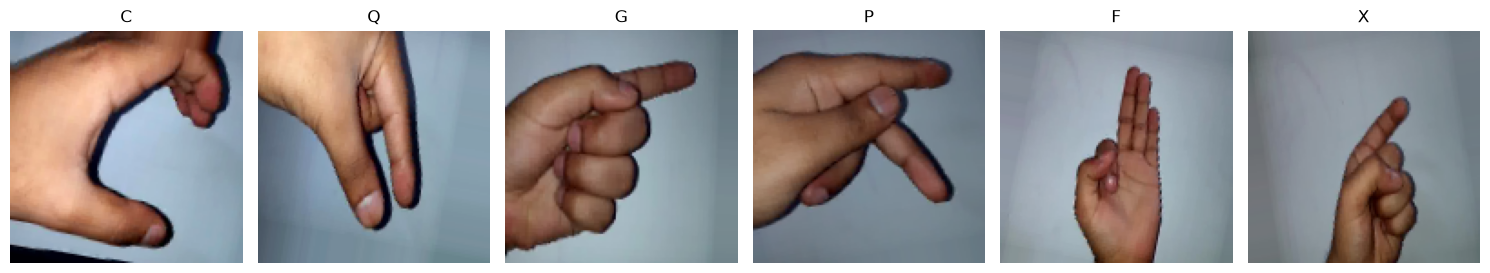

In [7]:
images, labels = next(train_generator)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(images[i])
    label_idx = np.argmax(labels[i])
    axes[i].set_title(class_names[label_idx])
    axes[i].axis('off')
plt.tight_layout()
plt.show()


**Observations:**
1. Confirms images and labels line up correctly after passing through the generator, before any time is spent building/training the model.
2. Images should look slightly rotated in some cases (from `rotation_range=10`) — this is the light augmentation applied only during training.
3. This is the last checkpoint to catch a labeling or preprocessing issue before moving to model architecture.

## 8. Simple CNN (From Scratch)

In [8]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

g:\Deep-Learning-Projects\IndiSignLang\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,123,960 (8.10 MB)

 Trainable params: 2,123,960 (8.10 MB)

 Non-trainable params: 0 (0.00 B)

**Observations:**
1. Three conv blocks, each halving image size (128->64->32->16) while increasing feature depth (16->32->64) — a standard, easy-to-explain CNN pattern for a from-scratch model.
2. No pretrained weights anywhere — every parameter is trained from scratch on your ISL data, matching the project brief's scope.
3. `model.summary()` prints the full layer breakdown and parameter count — worth including a screenshot of this in your report.

## 9. Compile the Model

In [9]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Observations:**
1. `categorical_crossentropy` pairs with `class_mode="categorical"` from Section 6 — both must match or training will error out.
2. `optimizer='adam'` uses Keras's default learning rate (0.001) — a reasonable, commonly-used starting point.
3. `metrics=['accuracy']` means accuracy is tracked automatically during training, printed every epoch without manual calculation.

## 10. Training Loop

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

NUM_EPOCHS = 30

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=NUM_EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 332ms/step - accuracy: 0.0660 - loss: 3.1935 - val_accuracy: 0.1477 - val_loss: 3.1401 - learning_rate: 5.0000e-04
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.0949 - loss: 3.1106 - val_accuracy: 0.2557 - val_loss: 2.9504 - learning_rate: 5.0000e-04
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.1528 - loss: 2.8550 - val_accuracy: 0.3466 - val_loss: 2.3969 - learning_rate: 5.0000e-04
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.2407 - loss: 2.5885 - val_accuracy: 0.3864 - val_loss: 2.0963 - learning_rate: 5.0000e-04
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.3056 - loss: 2.3448 - val_accuracy: 0.4659 - val_loss: 1.8501 - learning_rate: 5.0000e-04
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.3299 - loss: 2.1600 - val_accuracy: 0.5227 - val_loss: 1.5932 - learning_rate: 5.0000e-04
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy:

**Observations:**
1. Watch `accuracy` vs `val_accuracy` each epoch — a growing gap between them signals overfitting.
2. If val accuracy plateaus well before epoch 15, you could reduce `NUM_EPOCHS` next run; if still climbing at 15, consider increasing it.
3. Training time depends heavily on your device — CPU will be noticeably slower than GPU, that's expected, not an error.

## 11. Plot Training Curves

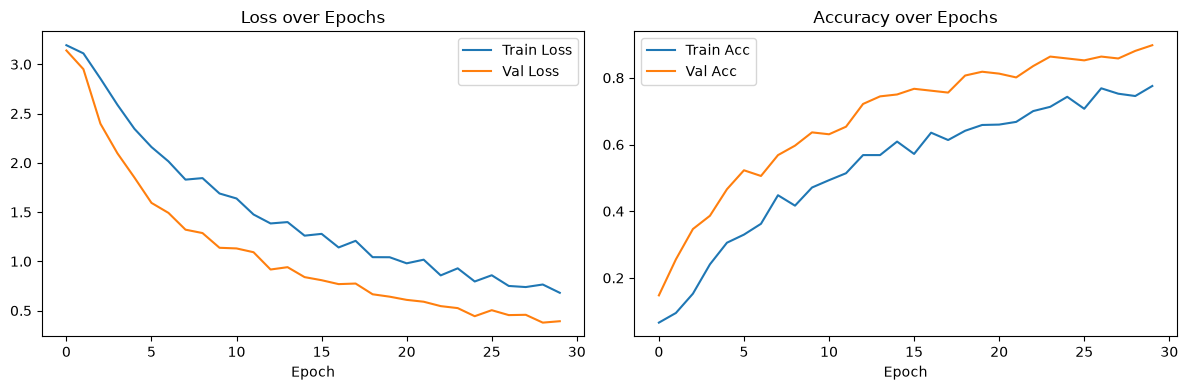

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label="Train Loss")
axes[0].plot(history.history['val_loss'], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['accuracy'], label="Train Acc")
axes[1].plot(history.history['val_accuracy'], label="Val Acc")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


**Observations:**
1. Loss curves should generally trend downward and flatten — a rising val loss late in training is a clear overfitting sign.
2. Train and val accuracy lines should stay reasonably close together — a large, widening gap between them signals overfitting.
3. This chart is worth including directly in your project report as visual evidence of training behavior.

## 12. Evaluate on Test Set

In [12]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.8066 - loss: 0.5875
Test Accuracy: 0.8066


**Observations:**
1. This is your true, held-out performance number — the one to report as your final result, not train or val accuracy.
2. Since test data is a later, different segment of the same recording sessions (per our sequential split), expect this to be somewhat lower than val accuracy — that's honest, not a bug.
3. If test accuracy is drastically lower than val accuracy, revisit the split logic — it may indicate leakage or a data issue rather than a modeling one.

## 13. Confusion Matrix & Per-Class Report

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step


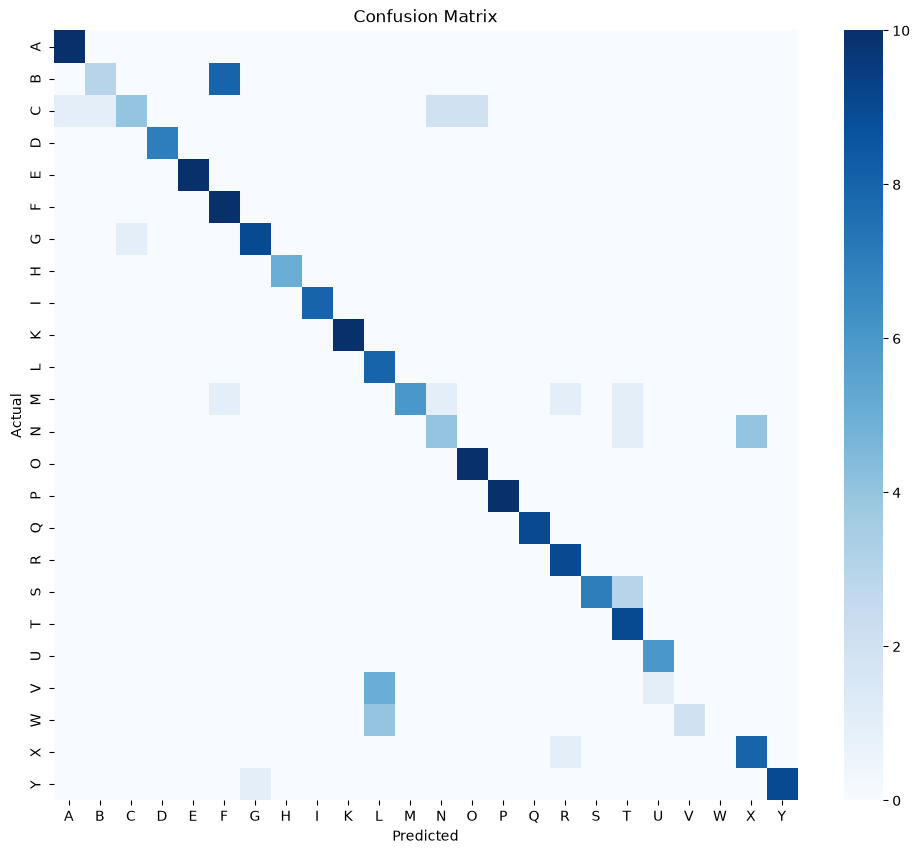

              precision    recall  f1-score   support

           A       0.91      1.00      0.95        10
           B       0.75      0.27      0.40        11
           C       0.80      0.40      0.53        10
           D       1.00      1.00      1.00         7
           E       1.00      1.00      1.00        10
           F       0.53      1.00      0.69        10
           G       0.90      0.90      0.90        10
           H       1.00      1.00      1.00         5
           I       1.00      1.00      1.00         8
           K       1.00      1.00      1.00        10
           L       0.47      1.00      0.64         8
           M       1.00      0.60      0.75        10
           N       0.57      0.44      0.50         9
           O       0.83      1.00      0.91        10
           P       1.00      1.00      1.00        10
           Q       1.00      1.00      1.00         9
           R       0.82      1.00      0.90         9
           S       1.00    

g:\Deep-Learning-Projects\IndiSignLang\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Deep-Learning-Projects\IndiSignLang\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Deep-Learning-Projects\IndiSignLang\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()
preds = model.predict(test_generator)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(true_classes, pred_classes, target_names=class_names))


**Observations:**
1. `test_generator.reset()` is important — without it, predictions can get misaligned with true labels, producing a misleading confusion matrix.
2. Look for bright off-diagonal cells — these show which letters get confused with each other, often visually similar hand shapes.
3. Cross-check weak classes here against the low-count classes identified in Section 2's EDA — low-data classes often perform worse, and this connects your EDA findings to your model results.

## 14. Save the Trained Model

In [14]:
MODEL_SAVE_PATH = r"G:\Deep-Learning-Projects\IndiSignLang\isl_simple_cnn.h5"
model.save(MODEL_SAVE_PATH)
print("Model saved to:", MODEL_SAVE_PATH)


Model saved to: G:\Deep-Learning-Projects\IndiSignLang\isl_simple_cnn.h5


**Observations:**
1. Keras saves the full model (architecture + weights) in one `.h5` file — no need for a separate class definition to reload it later.
2. Keep this file — it's your final deliverable for the 'ML model to predict the sign' part of the brief.
3. This completes both project goals: EDA + preprocessing (Sections 1-7) and the ML model (Sections 8-14).

---
## Summary

- **EDA:** class distribution, image dimensions/file sizes, sample images across classes, pixel intensity distribution
- **Preprocessing:** resize to 128x128, normalize (rescale 1/255), light rotation augmentation, sequential train/val/test split (from Notebook 1) to avoid frame-leakage
- **Model:** simple CNN from scratch (3 conv blocks + dense head), trained and evaluated
- **Evaluation:** training curves, test accuracy, confusion matrix, per-class precision/recall/F1
- **Output:** trained model saved as `isl_simple_cnn.h5`